# Machine Learning 2025W — Exercise 0  
### Dataset Description and Exploration (heart disease)

**Group Members:**  
- Full Name 1  
- Full Name 2  
- Full Name 3  

---


## 1. Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
import ssl
import certifi

ssl_context = ssl.create_default_context(cafile=certifi.where())

pd.set_option('display.max_columns', None)


In [14]:
import zipfile
import pandas as pd

# Path to your downloaded ZIP
zip_path = '/Users/addonn/Downloads/heart+disease (1).zip'

# Extract ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("heart_data")  # Extract to folder

# Now you have files like processed.cleveland.data inside heart_data/
data_path = "heart_data/processed.cleveland.data"

# Column names for the Heart Disease dataset
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv(data_path, names=columns)

# Split features and target
X = df.drop("target", axis=1)
y = df["target"]

print("Dataset shape:", df.shape)
df.head()



Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Load Dataset

In [10]:
# Fetch dataset by ID (45 = Heart Disease)
heart_disease = fetch_ucirepo(id=45)

# Split into features (X) and target (y)
X = heart_disease.data.features
y = heart_disease.data.targets

# Combine for convenience
df = pd.concat([X, y], axis=1)

print("Dataset shape:", df.shape)
df.head()

DatasetNotFoundError: Error reading data csv file for "Heart Disease" dataset (id=45).

## 3. Basic Information

In [15]:
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## 4. Target Variable

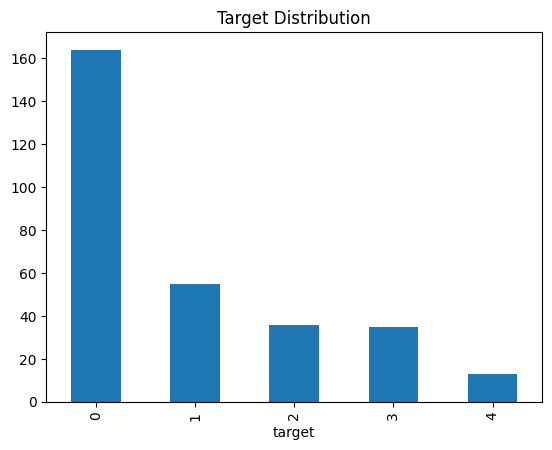

In [16]:
target_col = 'num'  # <-- replace with actual target column
sns.countplot(x=target_col, data=df)
plt.title('Presence of heart disease (target)')
plt.xlabel('Heart Disease Presence (num)')
plt.show()


## 5. Feature Exploration

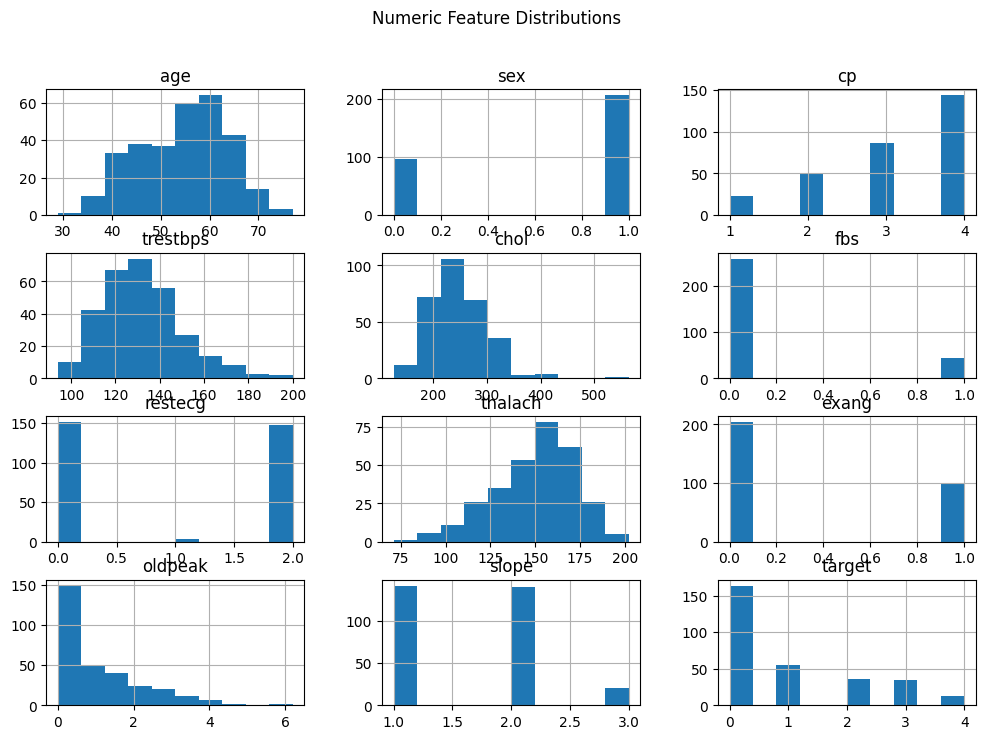

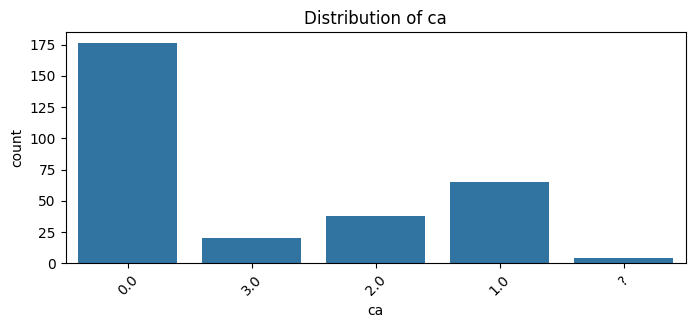

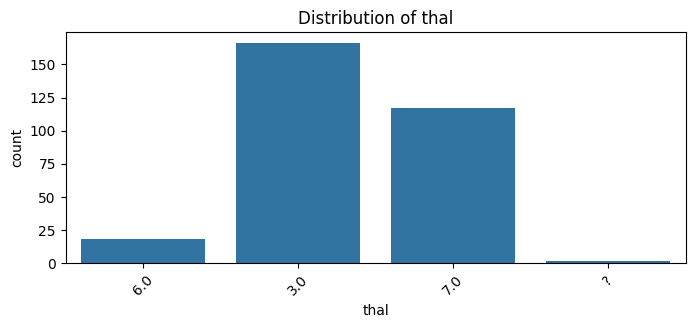

In [17]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].hist(figsize=(12, 8))
plt.suptitle("Numeric Feature Distributions")
plt.show()

cat_cols = df.select_dtypes(exclude=np.number).columns
for col in cat_cols:
    plt.figure(figsize=(8, 3))
    sns.countplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [12]:
corr = df.corr(numeric_only=True)
corr['num'].sort_values(ascending=False)

num         1.000000
ca          0.518909
thal        0.509923
oldpeak     0.504092
cp          0.407075
exang       0.397057
slope       0.377957
sex         0.224469
age         0.222853
restecg     0.183696
trestbps    0.157754
chol        0.070909
fbs         0.059186
thalach    -0.415040
Name: num, dtype: float64

## 6. Preprocessing Notes

In [18]:
# - Handle missing values
# - Normalize / scale numeric features
# - Encode categorical features

# Example: Standard scaling
# scaler = StandardScaler()
# df_scaled = pd.DataFrame(scaler.fit_transform(df[numeric_cols]), columns=numeric_cols)


## 7. Summary

In [ ]:
# Summarize dataset characteristics and preprocessing needs here